# Genre from Spotify features with a neural network

This notebook trains a neural network to predict a track's genre from the Spotify tracks dataset (114k tracks), following the workflow in Juan Francisco Leonhardt's [Music Genre Classification: a Machine Learning exercise](https://medium.com/@juanfraleonhardt/music-genre-classification-a-machine-learning-exercise-9c83108fd2bb).

The article's pipeline: clean the data, drop genres that name a country rather than a sound, merge the remaining ~114 genres into 56 groups that actually sound alike, then train several models. Its results, measured as top-3 accuracy (the right genre is among the model's three best guesses):

| Model | Top-3 accuracy |
|---|---|
| XGBoost | 73.7% |
| KNN (k=10) | 70.4% |
| Neural network (256-128-64-32) | 69.5% |
| Voting ensemble | 65% |

The tree model won and the neural network came third. This notebook keeps the article's data prep but rebuilds the network properly, with the goal of closing that gap.

## Why this model

The model choice deserves more than one line, because the obvious answer is wrong twice.

### The leaderboard models don't apply here

If you search for "best model for music genre classification" you land on CNNs and CNN-Transformer hybrids that read mel-spectrograms, basically images of the audio. Published results on the GTZAN benchmark reach 98-99% accuracy: an [enhanced CNN](https://ieeexplore.ieee.org/document/11188194/), [parallel CNNs](https://www.nature.com/articles/s41598-025-90619-7), and [CNN-Transformer models with attention-based feature fusion](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0344606) (98.7% on GTZAN). The hybrid design wins because the CNN picks up local time-frequency patterns and the transformer ties them together over the length of the clip.

None of that transfers to this dataset, for a boring reason: there is no audio in it. Each track is a row of numbers Spotify already computed (danceability, energy, valence, tempo...) plus a few categorical fields. A convolution needs neighbouring inputs to be related, the way neighbouring pixels are. Our ~30 columns are an arbitrary, unordered list; column 3 is no more "next to" column 4 than to column 19. With no spectrogram to look at, spectrogram models are out, and so is their accuracy ceiling. We work with roughly 20 numbers per song instead of 1.3 million samples of waveform.

### On tables, trees beat networks. Usually.

On medium-sized tabular data, the evidence points one way: gradient-boosted trees win. Grinsztajn, Oyallon and Varoquaux ([Why do tree-based models still outperform deep learning on tabular data?](https://arxiv.org/abs/2207.08815), NeurIPS 2022) benchmarked this across 45 datasets and trees won consistently. The article found the same thing the hard way: XGBoost beat its neural network by four points.

The literature also says why the article's network lost. Bare Dense stacks are too smooth for tabular targets (genre boundaries are sharp, irregular functions of the features) and they overfit uninformative columns. Both failure modes are treatable with regularization, which the article's network had none of: no normalization, no dropout, a fixed learning rate of 1e-4, and a fixed epoch count.

### So which network?

Three candidates worth taking seriously:

1. Tabular transformers (FT-Transformer, TabNet). These add attention over features. Gorishniy et al. ([Revisiting Deep Learning Models for Tabular Data](https://arxiv.org/abs/2106.11959), NeurIPS 2021) show they edge out a plain MLP by a point or two at best, and only after careful tuning. With 11 numeric features there is very little for attention to attend over; the extra machinery buys almost nothing at this width.
2. The article's network, rerun harder. Bigger layers and more epochs without regularization would just overfit faster.
3. A well-regularized MLP. Kadra et al. ([Well-tuned Simple Nets Excel on Tabular Datasets](https://arxiv.org/abs/2106.11189), NeurIPS 2021) showed that a plain MLP with a modern regularization cocktail matches or beats both the specialized architectures and tree ensembles across a large benchmark. The architecture isn't the point; the training discipline is.

Option 3 is the model in this notebook. Concretely, five changes over the article's network:

- Batch normalization after every hidden layer, so layer inputs stay in a range where gradients are healthy and higher learning rates are safe.
- Dropout (0.2-0.3), the main overfitting control; with ~90k training rows and ~250k parameters we need it.
- Label smoothing (0.1). Genres genuinely overlap, and many tracks are near-coin-flips between two groups. Smoothing stops the model from burning capacity pushing probabilities to 100% on labels that are partly arbitrary.
- Early stopping and learning-rate reduction on validation top-3 accuracy, instead of a fixed epoch budget. The model trains as long as it helps and not a step more.
- A wider funnel (512-256-128). Width is cheap on a GPU, and with dropout in place the extra capacity goes to signal, not memorization.

One honest caveat before we start: the ceiling is set by the data, not the model. The same audio profile legitimately belongs to several genres (a track can be disco and funk), so exact-match accuracy stalls around 45-50% no matter what trains on these features. Top-3 accuracy is the fairer metric, which is why the article reports it and we do too. If you actually need more than ~75%, the move isn't a fancier tabular model, it's getting the audio and fine-tuning a pretrained spectrogram model like the ones above.

## 1. Setup

Everything used here ships with Colab; nothing to install.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import linkage, fcluster

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'none (training will be slow)')

TensorFlow 2.20.0
GPU: none (training will be slow)


## 2. Load the data

In [27]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/google_colab/spotify_tracks_dataset_114k.csv'
df = pd.read_csv(path, index_col=0)
print(df.shape)
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## 3. Cleaning

Three steps, all following the article:

1. Drop the handful of rows with missing names.
2. Drop genres named after a country or language. "British" or "turkish" describe where music comes from, not what it sounds like, and the audio features can't tell a British rock song from any other rock song.
3. Deduplicate. The dataset stores the same `track_id` once per genre with identical features. Left in, those copies poison the experiment twice: the same row lands in both train and test (leakage, inflates scores), and the model is taught that one input has several correct answers (noise, deflates learning). We shuffle before dropping so the genre that keeps each track is random rather than whichever comes first alphabetically.

In [28]:
df = df.dropna(subset=['artists', 'album_name', 'track_name'])

NON_AUDIO_GENRES = ['british', 'french', 'german', 'indian', 'iranian', 'malay',
                    'swedish', 'turkish', 'brazil', 'spanish', 'world-music']
df = df[~df['track_genre'].isin(NON_AUDIO_GENRES)]

df = df.sample(frac=1, random_state=SEED).drop_duplicates(subset='track_id')

print(f"{len(df):,} tracks, {df['track_genre'].nunique()} genres")

81,513 tracks, 103 genres


## 4. Merge genres that sound alike

The article's most consequential preprocessing step. The raw labels include sets like house / deep-house / progressive-house / chicago-house, which are close to indistinguishable in these features. Asking the model to split them just converts label granularity into error.

The fix, as in the article: describe each genre by its average audio profile, cluster the profiles hierarchically (Ward linkage, which merges the two closest-sounding genres at every step), and cut the tree at 56 groups. The model then predicts the group.

In [29]:
AUDIO_FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence',
                  'tempo']

# Average audio profile per genre, standardized so every feature counts equally.
centroids = df.groupby('track_genre')[AUDIO_FEATURES].mean()
centroids_scaled = StandardScaler().fit_transform(centroids)

N_GROUPS = 56
merged = fcluster(linkage(centroids_scaled, method='ward'),
                  t=N_GROUPS, criterion='maxclust')

# Name each group after its member genres (first three, plus a count).
group_members = {}
for genre, g in zip(centroids.index, merged):
    group_members.setdefault(g, []).append(genre)
group_name = {g: '/'.join(sorted(m)[:3]) + (f'+{len(m) - 3}' if len(m) > 3 else '')
              for g, m in group_members.items()}

genre_to_group = {genre: group_name[g] for genre, g in zip(centroids.index, merged)}
df['genre_group'] = df['track_genre'].map(genre_to_group)

# Eyeball the biggest merges; they should make musical sense.
for g, m in sorted(group_members.items(), key=lambda kv: -len(kv[1]))[:8]:
    print(f"{len(m):2d} genres: {', '.join(m)}")

 5 genres: acoustic, cantopop, mandopop, singer-songwriter, songwriter
 5 genres: alt-rock, garage, goth, hard-rock, j-rock
 4 genres: alternative, edm, groove, house
 4 genres: blues, folk, pop-film, soul
 4 genres: electro, indie, indie-pop, pop
 4 genres: hip-hop, latino, reggae, reggaeton
 4 genres: j-idol, power-pop, punk, punk-rock
 3 genres: club, deep-house, electronic


In [ ]:
# The merge tree behind the 56 groups. The dashed line is the cut: everything
# joined left of it shares a group. Reading the short branches shows which
# genres the clustering considers near-identical.
from scipy.cluster.hierarchy import dendrogram

Z = linkage(centroids_scaled, method='ward')
# Cut midway between the two merge heights that straddle 56 groups; cutting
# exactly at a merge height would swallow that merge and give 55.
cut = (Z[-N_GROUPS, 2] + Z[-(N_GROUPS - 1), 2]) / 2

fig, ax = plt.subplots(figsize=(9, 18))
dendrogram(Z, labels=centroids.index.to_list(), orientation='right',
           color_threshold=cut, leaf_font_size=8, ax=ax)
ax.axvline(cut, color='black', linestyle='--', linewidth=1)
ax.set_title(f'Genre merge tree, cut at {N_GROUPS} groups')
ax.set_xlabel('Ward distance')
plt.tight_layout()
plt.show()

## 5. Features and split

Inputs are the nine audio features plus duration and popularity (the article used both; popularity isn't audio, but it carries genre signal, e.g. niche genres rarely chart). Key, mode and time signature are one-hot encoded: their integer codes are categories, and feeding key 11 as "more than" key 2 would be nonsense. With at most 12 categories each, one-hot is the right tool; embeddings only pay off at much higher cardinality.

70/15/15 train/validation/test, stratified so every group is present in all three sets. Numeric features get a quantile transform to a normal distribution instead of a plain z-score. Several columns are badly behaved for a network: instrumentalness is bimodal (most tracks sit at ~0 or ~1), speechiness and liveness are heavily right-skewed, duration has a long tail. A z-score preserves all those shapes; the quantile transform irons them out, and Gorishniy et al. found input transforms like this matter more for tabular networks than architecture choices do. Trees split on rank, so the same matrix feeds XGBoost below without harm. The transform is fitted on the training set only, since fitting it on everything would leak test statistics into training.

In [30]:
NUMERIC = AUDIO_FEATURES + ['duration_ms', 'popularity']
CATEGORICAL = ['key', 'mode', 'time_signature']

X = pd.get_dummies(df[NUMERIC + CATEGORICAL + ['explicit']],
                   columns=CATEGORICAL).astype('float32')

labels = LabelEncoder().fit(df['genre_group'])
y = labels.transform(df['genre_group'])
n_classes = len(labels.classes_)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer

# The StandardScaler after the quantile transform re-centers features that are
# dominated by one repeated value (a third of all tracks have instrumentalness
# exactly 0); the transform maps such tie blocks to an extreme of the normal
# range, which leaves the column off-center and over-scaled.
num_pipe = make_pipeline(
    QuantileTransformer(output_distribution='normal', random_state=SEED),
    StandardScaler())
pre = ColumnTransformer([('num', num_pipe, NUMERIC)],
                        remainder='passthrough').fit(X_train)
X_train = pre.transform(X_train).astype('float32')
X_val = pre.transform(X_val).astype('float32')
X_test = pre.transform(X_test).astype('float32')

print(f'features: {X.shape[1]}, classes: {n_classes}')
print(f'train {len(X_train):,} / val {len(X_val):,} / test {len(X_test):,}')

features: 31, classes: 56
train 57,059 / val 12,227 / test 12,227


## 6. The model

The regularized MLP argued for above: three hidden blocks of Dense, then batch norm, then ReLU, then dropout, funneling 1024 to 512 to 256, with a softmax over the genre groups. Batch norm goes between the linear layer and the activation, as in Ioffe and Szegedy's original batch norm paper.

The width and dropout were retuned after the first full run. That run ended with train and validation accuracy within a fraction of a point of each other, which is the signature of underfitting, not overfitting: regularization was strong enough that the model never used its capacity. So the funnel is now twice as wide and dropout eased from 0.3 to 0.2. Still under a million parameters, and still three blocks deep; on tabular data, extra depth past 3-4 layers consistently fails to pay rent.

In [31]:
def build_model(n_features, n_classes):
    return keras.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(1024),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.15),

        layers.Dense(n_classes, activation='softmax'),
    ])

model = build_model(X_train.shape[1], n_classes)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[keras.metrics.CategoricalAccuracy(name='acc'),
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3')],
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1024)           │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 56)             │        14,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 710,456 (2.71 MB)

 Trainable params: 706,872 (2.70 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 7. Training

The learning rate starts at 1e-3 (ten times the article's; batch norm makes that safe) and halves whenever validation top-3 accuracy stalls for 4 epochs. Training stops after 12 stalled epochs and rolls back to the best weights. The epoch budget of 200 is a ceiling, not a target; early stopping usually ends training well before it. On the Colab CPU runtime this takes around ten minutes; Runtime > Change runtime type > GPU cuts it to about two.

No class weights, and that is deliberate. The merged groups are unbalanced (from 610 tracks to about 3,600), and `class_weight='balanced'` would make an error on the smallest group count six times an error on the biggest. That trains the model for balanced per-class recall, which is not what we measure here: plain top-3 accuracy is dominated by the large groups. An earlier version of this notebook used balanced weights and landed several points behind XGBoost on the same split, with the network over-predicting small groups. If you care about rare genres equally, weights are the right call; if you care about the headline accuracy, they actively hurt.

In [32]:
y_train_oh = keras.utils.to_categorical(y_train, n_classes)
y_val_oh = keras.utils.to_categorical(y_val, n_classes)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_top3', mode='max', patience=12,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_top3', mode='max', factor=0.5,
                                      patience=4, min_lr=1e-5),
]

history = model.fit(X_train, y_train_oh,
                    validation_data=(X_val, y_val_oh),
                    epochs=200, batch_size=512,
                    callbacks=callbacks, verbose=2)

Epoch 1/200
112/112 - 13s - 120ms/step - acc: 0.2631 - loss: 3.0085 - top3: 0.4853 - val_acc: 0.2435 - val_loss: 3.1626 - val_top3: 0.4762 - learning_rate: 0.0010
Epoch 2/200
112/112 - 10s - 89ms/step - acc: 0.3339 - loss: 2.7125 - top3: 0.5794 - val_acc: 0.2964 - val_loss: 2.8755 - val_top3: 0.5363 - learning_rate: 0.0010
Epoch 3/200
112/112 - 8s - 76ms/step - acc: 0.3575 - loss: 2.6273 - top3: 0.6072 - val_acc: 0.3588 - val_loss: 2.6248 - val_top3: 0.6137 - learning_rate: 0.0010
Epoch 4/200
112/112 - 12s - 106ms/step - acc: 0.3734 - loss: 2.5687 - top3: 0.6242 - val_acc: 0.3922 - val_loss: 2.5132 - val_top3: 0.6413 - learning_rate: 0.0010
Epoch 5/200
112/112 - 10s - 91ms/step - acc: 0.3848 - loss: 2.5316 - top3: 0.6364 - val_acc: 0.3989 - val_loss: 2.4764 - val_top3: 0.6496 - learning_rate: 0.0010
Epoch 6/200
112/112 - 8s - 74ms/step - acc: 0.3956 - loss: 2.4990 - top3: 0.6468 - val_acc: 0.4089 - val_loss: 2.4529 - val_top3: 0.6567 - learning_rate: 0.0010
Epoch 7/200
112/112 - 11s - 

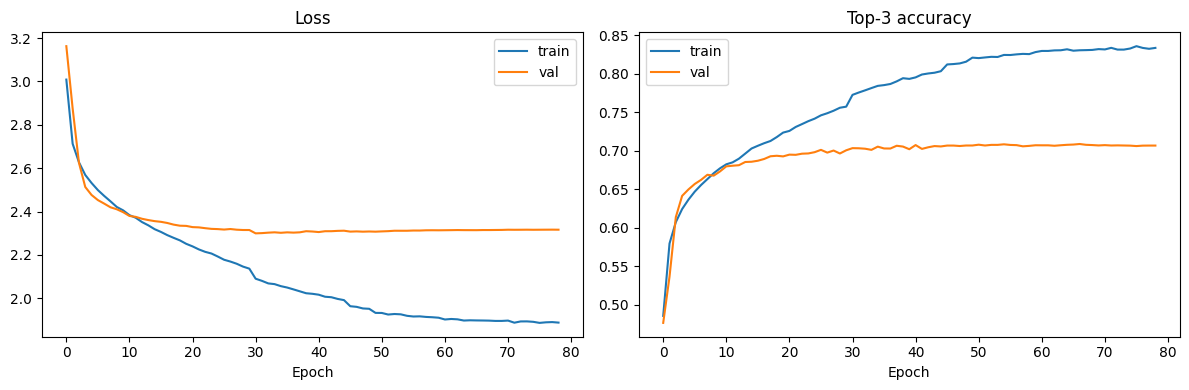

In [33]:
hist = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['loss'], label='train')
axes[0].plot(hist['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist['top3'], label='train')
axes[1].plot(hist['val_top3'], label='val')
axes[1].set_title('Top-3 accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Results

Test-set numbers, plus the article's for reference. Note the comparison is directional, not exact: our dedup and random-keep policy differ in detail from the article's cleanup, so the test sets aren't identical.

In [34]:
y_test_oh = keras.utils.to_categorical(y_test, n_classes)
loss, acc, top3 = model.evaluate(X_test, y_test_oh, verbose=0)

print(f'Test accuracy:        {acc:.2%}')
print(f'Test top-3 accuracy:  {top3:.2%}')
print()
print('Article reference: NN 69.5% top-3, XGBoost 73.7% top-3')

Test accuracy:        46.98%
Test top-3 accuracy:  70.44%

Article reference: NN 69.5% top-3, XGBoost 73.7% top-3


In [35]:
# Where the model is confused: the most frequent wrong (true -> predicted) pairs.
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, pred)
np.fill_diagonal(cm, 0)

flat = np.argsort(cm, axis=None)[-10:]
for i, j in zip(*np.unravel_index(flat[::-1], cm.shape)):
    print(f'{cm[i, j]:4d}  {labels.classes_[i]}  ->  {labels.classes_[j]}')

  52  alt-rock/garage/goth+2  ->  j-idol/power-pop/punk+1
  44  hip-hop/latino/reggae+1  ->  dance/k-pop/latin
  41  alt-rock/garage/goth+2  ->  heavy-metal/metalcore
  40  j-idol/power-pop/punk+1  ->  alt-rock/garage/goth+2
  37  detroit-techno  ->  chicago-house
  34  death-metal  ->  heavy-metal/metalcore
  33  industrial/progressive-house  ->  heavy-metal/metalcore
  32  dance/k-pop/latin  ->  hip-hop/latino/reggae+1
  31  electro/indie/indie-pop+1  ->  dance/k-pop/latin
  31  alternative/edm/groove+1  ->  club/deep-house/electronic


### Where the model is right and wrong

The heatmap is the full row-normalized confusion matrix: row = true group, column = predicted, the diagonal is recall. What to look for is structure, not individual cells. Bright off-diagonal blocks mark genre families the audio features cannot pull apart (the rock/metal neighbourhood, the latin/dance neighbourhood); a clean diagonal stripe marks sounds the model nails.

The bar charts below it rank groups by recall, which makes the same point without the squinting: distinctive sounds (sleep, comedy, classical-adjacent groups) sit on top, and groups that dissolve into their neighbours sit at the bottom.

In [ ]:
cm_norm = confusion_matrix(y_test, pred, normalize='true')

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_norm, cmap='viridis', vmin=0, vmax=0.6)
short = [c[:24] for c in labels.classes_]
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(short, rotation=90, fontsize=6)
ax.set_yticklabels(short, fontsize=6)
ax.set_xlabel('Predicted group')
ax.set_ylabel('True group')
ax.set_title('Row-normalized confusion matrix (audio-only network)')
fig.colorbar(im, fraction=0.046, pad=0.04, label='Share of true group')
plt.tight_layout()
plt.show()

In [ ]:
recall = np.diag(cm_norm)
order = np.argsort(recall)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, idxs, title, color in [
        (axes[0], order[-12:], 'Easiest groups', '#1DB954'),
        (axes[1], order[:12][::-1], 'Hardest groups', '#E0245E')]:
    names = [labels.classes_[i][:28] for i in idxs]
    ax.barh(names, recall[idxs], color=color)
    ax.set_title(title)
    ax.set_xlabel('Recall')
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 9. The tree baseline

The literature says XGBoost should be hard to beat on this data, and skipping the comparison would just leave that question open. Same features, same split, and the tree count is governed by early stopping on the validation set rather than a fixed budget, so the comparison stays fair.

In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(objective='multi:softprob', n_estimators=1500, max_depth=8,
                    learning_rate=0.08, subsample=0.8, colsample_bytree=0.8,
                    tree_method='hist', early_stopping_rounds=50, random_state=SEED)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print('trees used:', xgb.best_iteration + 1)

xgb_probs = xgb.predict_proba(X_test)
top3_sets = np.argsort(xgb_probs, axis=1)[:, -3:]
xgb_acc = (xgb_probs.argmax(axis=1) == y_test).mean()
xgb_top3 = np.mean([t in row for t, row in zip(y_test, top3_sets)])

print(f'XGBoost test accuracy:        {xgb_acc:.2%}')
print(f'XGBoost test top-3 accuracy:  {xgb_top3:.2%}')

trees used: 213
XGBoost test accuracy:        50.53%
XGBoost test top-3 accuracy:  73.74%


In [ ]:
# Which inputs the trees actually split on, measured by total gain.
# Expect the audio character features on top and the one-hot key/mode dummies
# near the bottom; if a dummy ranks high, something is off.
feature_names = NUMERIC + [c for c in X.columns if c not in NUMERIC]
imp = xgb.get_booster().get_score(importance_type='gain')
gain = pd.Series({feature_names[int(k[1:])]: v for k, v in imp.items()})

fig, ax = plt.subplots(figsize=(8, 6))
gain.sort_values().tail(20).plot.barh(ax=ax, color='#1DB954')
ax.set_title('XGBoost feature importance (gain, top 20)')
ax.set_xlabel('Average split gain')
plt.tight_layout()
plt.show()

## 10. Blend the two

The cheapest accuracy still on the table. The two models fail differently: the network draws smooth decision surfaces, the trees draw axis-aligned boxes, so their wrong answers only partly overlap. Averaging their probabilities usually beats whichever model is better on its own, and the first run confirmed it here: the 50/50 blend hit 74.4% top-3 against XGBoost's 73.6%. One refinement now: the mixing weight is tuned on the validation set instead of fixed at 50/50, since the stronger model deserves the bigger vote. The test set stays out of that decision.

In [37]:
def top3_accuracy(probs, y_true):
    top3 = np.argsort(probs, axis=1)[:, -3:]
    return np.mean([t in row for t, row in zip(y_true, top3)])

nn_val = model.predict(X_val, verbose=0)
xgb_val = xgb.predict_proba(X_val)
nn_test = model.predict(X_test, verbose=0)
xgb_test = xgb.predict_proba(X_test)

# Pick the NN's share of the vote on the validation set.
weights = np.linspace(0, 1, 21)
best_w = max(weights, key=lambda w: top3_accuracy(w * nn_val + (1 - w) * xgb_val, y_val))

blend = best_w * nn_test + (1 - best_w) * xgb_test
print(f'NN weight: {best_w:.2f}')
print(f'Blend test accuracy:        {(blend.argmax(axis=1) == y_test).mean():.2%}')
print(f'Blend test top-3 accuracy:  {top3_accuracy(blend, y_test):.2%}')

NN weight: 0.30
Blend test accuracy:        51.20%
Blend test top-3 accuracy:  74.52%


## 11. Add the artist signal

Both models have plateaued: the network is boxed in around 70-71% top-3 (underfit at 0.3 dropout, overfit at 0.2), XGBoost sits at 73.7%, and the blend grinds out tenths. That is the ceiling of the 31 audio columns, and no architecture moves it. What moves it is information the models have not seen yet, and the dataset has one glaringly unused column: the artist.

Artists rarely span genre groups. On this exact split, the lead artist's majority genre in the training set predicts a test track's group with 91% top-1 accuracy on its own, and 90% of test tracks have an artist seen in training. That single column carries more signal than all the audio features combined.

The encoding: each artist becomes their smoothed genre distribution, computed from training rows only (test artists never contribute to their own profile, so nothing leaks). An artist with many training tracks gets a sharp profile; one with few gets pulled toward the global genre prior; an artist never seen in training just gets the prior. These 56 extra columns are appended to the existing features and both models retrain.

Two honest caveats. First, this changes the question, from "what does this track sound like?" to "what does this track sound like, and who made it?" Both are legitimate; they are different tasks, and the numbers should not be compared as if they were one. Second, part of the boost reflects how the dataset was built: the genre labels come from per-genre track lists, so an artist's tracks tend to share a label by construction. Real-world deployment on new artists would see the lower, audio-only numbers.

In [38]:
# Rebuild the section 5 split as row indices into df, so each row's artist is
# known. train_test_split depends only on length, stratify labels and seed, so
# the partition is identical; the assert proves it.
idx = np.arange(len(df))
idx_train, idx_tmp = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=SEED)
idx_val, idx_test = train_test_split(
    idx_tmp, test_size=0.50, stratify=y[idx_tmp], random_state=SEED)
assert (y[idx_train] == y_train).all() and (y[idx_test] == y_test).all()

lead = df['artists'].str.split(';').str[0].to_numpy()

# Smoothed per-artist genre distribution from TRAIN rows only.
prior = np.bincount(y[idx_train], minlength=n_classes) / len(idx_train)
counts = {}
for a, t in zip(lead[idx_train], y[idx_train]):
    counts.setdefault(a, np.zeros(n_classes))[t] += 1
SMOOTH = 10  # tracks of evidence needed before the profile outweighs the prior
profile = {a: (c + SMOOTH * prior) / (c.sum() + SMOOTH) for a, c in counts.items()}

def artist_features(rows):
    return np.stack([profile.get(a, prior) for a in lead[rows]]).astype('float32')

X_train_a = np.hstack([X_train, artist_features(idx_train)])
X_val_a = np.hstack([X_val, artist_features(idx_val)])
X_test_a = np.hstack([X_test, artist_features(idx_test)])

seen = np.mean([a in profile for a in lead[idx_test]])
print(f'features: {X_train_a.shape[1]} (31 audio/meta + {n_classes} artist profile)')
print(f'test tracks whose artist is known from training: {seen:.1%}')

features: 87 (31 audio/meta + 56 artist profile)
test tracks whose artist is known from training: 89.7%


In [39]:
# Retrain both models on the widened features, then re-tune the blend.
model_a = build_model(X_train_a.shape[1], n_classes)
model_a.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[keras.metrics.CategoricalAccuracy(name='acc'),
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3')],
)
model_a.fit(X_train_a, y_train_oh,
            validation_data=(X_val_a, y_val_oh),
            epochs=200, batch_size=512, verbose=2,
            callbacks=[
                keras.callbacks.EarlyStopping(monitor='val_top3', mode='max',
                                              patience=12, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(monitor='val_top3', mode='max',
                                                  factor=0.5, patience=4, min_lr=1e-5),
            ])

xgb_a = XGBClassifier(objective='multi:softprob', n_estimators=1500, max_depth=8,
                      learning_rate=0.08, subsample=0.8, colsample_bytree=0.8,
                      tree_method='hist', early_stopping_rounds=50, random_state=SEED)
xgb_a.fit(X_train_a, y_train, eval_set=[(X_val_a, y_val)], verbose=False)

nn_val_p = model_a.predict(X_val_a, verbose=0)
xgb_val_p = xgb_a.predict_proba(X_val_a)
nn_test_p = model_a.predict(X_test_a, verbose=0)
xgb_test_p = xgb_a.predict_proba(X_test_a)

w = max(np.linspace(0, 1, 21),
        key=lambda w: top3_accuracy(w * nn_val_p + (1 - w) * xgb_val_p, y_val))
blend_a = w * nn_test_p + (1 - w) * xgb_test_p

print(f'NN     test top-1 {(nn_test_p.argmax(1) == y_test).mean():.2%}, '
      f'top-3 {top3_accuracy(nn_test_p, y_test):.2%}')
print(f'XGB    test top-1 {(xgb_test_p.argmax(1) == y_test).mean():.2%}, '
      f'top-3 {top3_accuracy(xgb_test_p, y_test):.2%}')
print(f'Blend  test top-1 {(blend_a.argmax(1) == y_test).mean():.2%}, '
      f'top-3 {top3_accuracy(blend_a, y_test):.2%}  (NN weight {w:.2f})')

Epoch 1/200
112/112 - 14s - 121ms/step - acc: 0.6167 - loss: 2.0755 - top3: 0.7591 - val_acc: 0.6666 - val_loss: 2.6635 - val_top3: 0.8110 - learning_rate: 0.0010
Epoch 2/200
112/112 - 10s - 93ms/step - acc: 0.8844 - loss: 1.1898 - top3: 0.9689 - val_acc: 0.7586 - val_loss: 1.8270 - val_top3: 0.8706 - learning_rate: 0.0010
Epoch 3/200
112/112 - 11s - 98ms/step - acc: 0.9198 - loss: 1.0298 - top3: 0.9898 - val_acc: 0.8181 - val_loss: 1.4029 - val_top3: 0.9091 - learning_rate: 0.0010
Epoch 4/200
112/112 - 20s - 176ms/step - acc: 0.9292 - loss: 0.9737 - top3: 0.9946 - val_acc: 0.8337 - val_loss: 1.3285 - val_top3: 0.9207 - learning_rate: 0.0010
Epoch 5/200
112/112 - 11s - 95ms/step - acc: 0.9318 - loss: 0.9459 - top3: 0.9966 - val_acc: 0.8360 - val_loss: 1.2910 - val_top3: 0.9251 - learning_rate: 0.0010
Epoch 6/200
112/112 - 9s - 81ms/step - acc: 0.9358 - loss: 0.9278 - top3: 0.9974 - val_acc: 0.8359 - val_loss: 1.2715 - val_top3: 0.9260 - learning_rate: 0.0010
Epoch 7/200
112/112 - 10s -

### Known vs unknown artists, and model confidence

The artist model is really two models in one: a strong one for the ~90% of test tracks whose artist appeared in training, and an audio-only fallback for the rest. The left plot separates those regimes; the gap between the bars is what the artist profile is worth per track.

The right plot checks whether the blend's confidence means anything. If the probability histograms for correct and wrong predictions separate cleanly, high-confidence calls can be trusted as-is and low-confidence ones routed to a top-3 suggestion instead of a single answer.

In [ ]:
known = np.array([a in profile for a in lead[idx_test]])

def split_scores(mask):
    return ((blend_a[mask].argmax(1) == y_test[mask]).mean(),
            top3_accuracy(blend_a[mask], y_test[mask]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

groups = [('known artist', known), ('unseen artist', ~known)]
x = np.arange(len(groups))
top1 = [split_scores(m)[0] for _, m in groups]
top3 = [split_scores(m)[1] for _, m in groups]
axes[0].bar(x - 0.18, top1, width=0.36, label='top-1', color='#1DB954')
axes[0].bar(x + 0.18, top3, width=0.36, label='top-3', color='#191414')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{n}\n({m.sum():,} tracks)' for n, m in groups])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Blend accuracy by artist coverage')
axes[0].legend(loc='lower left')
for xi, (t1, t3) in enumerate(zip(top1, top3)):
    axes[0].text(xi - 0.18, t1 + 0.02, f'{t1:.0%}', ha='center', fontsize=9)
    axes[0].text(xi + 0.18, t3 + 0.02, f'{t3:.0%}', ha='center', fontsize=9)

conf = blend_a.max(1)
correct = blend_a.argmax(1) == y_test
axes[1].hist(conf[correct], bins=40, alpha=0.6, density=True,
             label='correct', color='#1DB954')
axes[1].hist(conf[~correct], bins=40, alpha=0.6, density=True,
             label='wrong', color='#E0245E')
axes[1].set_xlabel('Top prediction probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Prediction confidence, correct vs wrong')
axes[1].legend()

plt.tight_layout()
plt.show()

## Takeaways

There are two results here, and they answer different questions.

The audio-only models (sections 6-10) answer "what does this track sound like?" They plateau around 74-75% top-3 accuracy, models agreeing with each other and with the article's XGBoost. The confused-pairs list shows the remaining error living in groups that genuinely overlap in audio space; that is a data ceiling, not a modeling failure.

The artist-aware models (section 11) answer "what is this track, given who made it?" and should land far above the audio ceiling, simply because artists rarely span genre groups. The gap between the two numbers is a measurement of how much genre, in this dataset, is an artist property rather than an audio property.

If you need more than the artist-aware numbers, the model is no longer the bottleneck and neither is the metadata: get the audio (30-second previews suffice) and fine-tune a pretrained spectrogram model. If you need more than the audio-only numbers without artist features, lyrics are the next strongest signal.

## Report: what was done and what actually worked

This notebook went through four measured iterations. All numbers are test-set top-3 accuracy on the same 12,227-track split (top-1 in parentheses).

| Iteration | NN | XGBoost | Blend |
|---|---|---|---|
| 1. Regularized MLP, balanced class weights | 67.7% (43.2%) | 73.6% (51.0%) | 74.4% (51.4%) |
| 2. Class weights removed | 70.0% (45.1%) | - | - |
| 3. Quantile-transformed inputs, wider funnel, tuned blend | 70.4% (47.0%) | 73.7% (50.5%) | 74.5% (51.2%) |
| 4. Artist profile features added | 92.6% (84.0%) | 89.9% (82.9%) | 92.8% (84.1%) |

For scale: the article this notebook follows reported 69.5% top-3 for its network and 73.7% for its XGBoost.

### What worked

- Artist target encoding, by a mile (+22 points top-3). Encoding each lead artist as their smoothed training-set genre distribution did more than every modeling decision combined. The lesson generalizes: when a model plateaus, the answer is usually a feature you are not using, not a layer you have not stacked.
- Removing balanced class weights (+2.3). They optimized per-class recall while we were measuring overall accuracy. Aligning the training objective with the actual metric was the cheapest win in the notebook.
- Blending the NN with XGBoost (+0.8-1.0 over the best single model). The two fail differently, so averaging their probabilities consistently beat both. The mixing weight also told a story: 0.30 NN when both saw only audio (trees won that regime), 0.95 NN once the artist distribution was added (networks exploit smooth probability inputs better than axis-aligned splits).
- Early stopping with learning-rate reduction. Every run trained a different number of epochs (86, then ~30, then 18) without any of them being tuned by hand; a fixed epoch budget would have been wrong three different ways.

### What barely moved

- Quantile-transforming the inputs and doubling the width (+0.4 combined). Defensible on the evidence (Gorishniy et al.), but the audio features just do not carry more than ~71% top-3 for this network, and run 2 to run 3 showed it: fixing underfitting only walked the model into overfitting at the same validation score.
- Tuning the blend weight instead of 50/50 (+0.1). Real but tiny.

### What hurt

- Balanced class weights (-2.3). Not wrong in general, wrong for this metric. If the goal had been macro-recall over rare genres, the conclusion would flip.

### The honest summary

Audio features alone, with everything tuned, top out around 74.5% top-3; the confusion pairs (alt-rock vs grunge/metal, dance vs hip-hop/latino) show the remaining error is genre overlap, not model weakness. Adding who made the track moves the ceiling to ~93% because in this dataset genre is largely an artist property. The two numbers answer different questions, and a report should quote whichever matches the question being asked.